In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Build the plotting core

In [2]:
from matplotlib.lines import Line2D
import cartopy.feature as cfeature
from matplotlib.patches import FancyArrowPatch

def initialize_time_slice_map_plot_large():

    linewidths_runs = 20
    linewidths_gwls = 1

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------

    fig = plt.figure(figsize=(16, 8))

    # --------------------------------------------------
    # Manually define subplot positions
    # [left, bottom, width, height]
    # coordinates are figure fractions
    # --------------------------------------------------


    x_ramp_start = 0.1
    x_ramp_width = 0.2
    x_stab_width = 0.2
    
    width = 0.18
    height = 0.2

    positions = [

        #rampup
        [x_ramp_start-width/2, 0.1-height/2, width, height],
        [x_ramp_start+x_ramp_width/4-width/2, 0.3-height/2, width, height],
        [x_ramp_start+x_ramp_width/2-width/2, 0.5-height/2, width, height],
        [x_ramp_start+x_ramp_width*3/4-width/2, 0.7-height/2, width, height],
        [x_ramp_start+x_ramp_width-width/2, 0.9-height/2, width, height],

        # stabilizations
        [x_ramp_start+x_ramp_width/2+x_stab_width-width/2, 0.5-height/2, width, height],
        [x_ramp_start+x_ramp_width+x_stab_width-width/2, 0.9-height/2, width, height],

        #2K rampdown
        [x_ramp_start+x_ramp_width/2+x_stab_width+x_ramp_width/4-width/2, 0.3-height/2, width, height],
        [x_ramp_start+x_ramp_width/2+x_stab_width+x_ramp_width/2-width/2, 0.1-height/2, width, height],

        #4K rampdown
        [x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width*1/4-width/2, 0.7-height/2, width, height],
        [x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width/2-width/2, 0.5-height/2, width, height],
        [x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width*3/4-width/2, 0.3-height/2, width, height],
        [x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width-width/2, 0.1-height/2, width, height],

        # restab
        [x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width/2+x_stab_width-width/2, 0.5-height/2, width, height],
    ]

    ax_names = ['piC_at_start',
                'rampup_1K',
                'rampup_2K',
                'rampup_3K',
                'rampup_4K',

                'stab2K',
                'stab4K',

                'rampdn2K_1K',
                'rampdn2K_0K',

                'rampdn4K_3K',
                'rampdn4K_2K',     
                'rampdn4K_1K',
                'rampdn4K_0K',             

                'restab2K',     
               ]

    # --------------------------------------------------
    # Add figure-level structure lines
    # --------------------------------------------------

    y_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
    y_labels = ['0K', '1K', '2K', '3K', '4K']

    for y, label in zip(y_levels, y_labels):

        line = Line2D(
            [0.06, 0.65],
            [y, y],
            transform=fig.transFigure,
            color='black',
            linewidth=2,
            linestyle='--',
            alpha=0.4,
            zorder=0
        )

        fig.add_artist(line)

        # GWL labels
        fig.text(
            0.03,
            y,
            label,
            va='center',
            ha='left',
            fontsize=18,
            fontweight='bold'
        )

    # piC label
    fig.text(
        0.18,
        0.03,
        'piC',
        va='center',
        ha='left',
        fontsize=18,
        fontweight='bold'
    )

    # 2K stab label
    fig.text(
        0.48, #         [x_ramp_start+x_ramp_width/2+x_stab_width-width/2, 0.5-height/2, width, height],
        0.43,
        '2Ks',
        va='center',
        ha='left',
        fontsize=18,
        fontweight='bold'
    )

    # 4K stab label
    fig.text(
        0.58, #         [x_ramp_start+x_ramp_width/2+x_stab_width-width/2, 0.5-height/2, width, height],
        0.83,
        '4Ks',
        va='center',
        ha='left',
        fontsize=18,
        fontweight='bold'
    )

    # 2K restab label
    fig.text(
        0.88, #         [x_ramp_start+x_ramp_width/2+x_stab_width-width/2, 0.5-height/2, width, height],
        0.43,
        '2Krs',
        va='center',
        ha='left',
        fontsize=18,
        fontweight='bold'
    )

    # --------------------------------------------------
    # Trajectory lines
    # --------------------------------------------------

    def add_line(x0, y0, x1, y1, color):

        line = Line2D(
            [x0, x1],
            [y0, y1],
            transform=fig.transFigure,
            color=color,
            linestyle='-',
            linewidth=linewidths_runs,
            solid_capstyle='round',
            zorder=1
        )

        fig.add_artist(line)

    # piControl
    add_line(x_ramp_start, 0.1, 0.9, 0.1, '#555555')

    # rampup
    add_line(x_ramp_start, 0.1, x_ramp_start+x_ramp_width, 0.9, 'C1')

    # stab 2K
    add_line(x_ramp_start+x_ramp_width/2, 0.5, x_ramp_start+x_ramp_width/2+x_stab_width, 0.5, 'C2')

    # stab 4K
    add_line(x_ramp_start+x_ramp_width, 0.9, x_ramp_start+x_ramp_width+x_stab_width, 0.9, 'C2')

    # rampdown 2K
    add_line(x_ramp_start+x_ramp_width/2+x_stab_width, 0.5, x_ramp_start+x_ramp_width/2+x_stab_width+x_ramp_width/2, 0.1, 'C0')

    # rampdown 4K
    add_line(x_ramp_start+x_ramp_width+x_stab_width, 0.9, x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width, 0.1, 'C0')

    # restab 2K
    add_line(x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width/2, 0.5, x_ramp_start+x_ramp_width+x_stab_width+x_ramp_width/2+x_stab_width, 0.5, 'C3')

    # --------------------------------------------------
    # GWL Arrow
    # --------------------------------------------------

    arrow = FancyArrowPatch(
        (0.02, 0.1),
        (0.02, 0.93),
        transform=fig.transFigure,
        arrowstyle='-|>',
        linewidth=10,
        color='black',
        mutation_scale=80,
        zorder=2
    )

    fig.add_artist(arrow)

    # Arrow title
    fig.text(
        0.02,
        0.925,
        'GWL',
        ha='center',
        va='bottom',
        fontsize=16,
        fontweight='bold',
        rotation=0
    )

    # --------------------------------------------------
    # Create Cartopy axes
    # --------------------------------------------------

    axes = dict()

    for pos,ax_name in zip(positions,ax_names):

        ax = fig.add_axes(
            pos,
            projection=ccrs.Robinson(central_longitude=250),
            zorder=10   # bring panels to foreground
        )

        ax.set_global()

        ax.coastlines(linewidth=1)#0.5)

        ax.add_feature(
            cfeature.LAND,
            facecolor='none',#'lightgray'
        )

        axes[ax_name] = ax
        
    return fig, axes

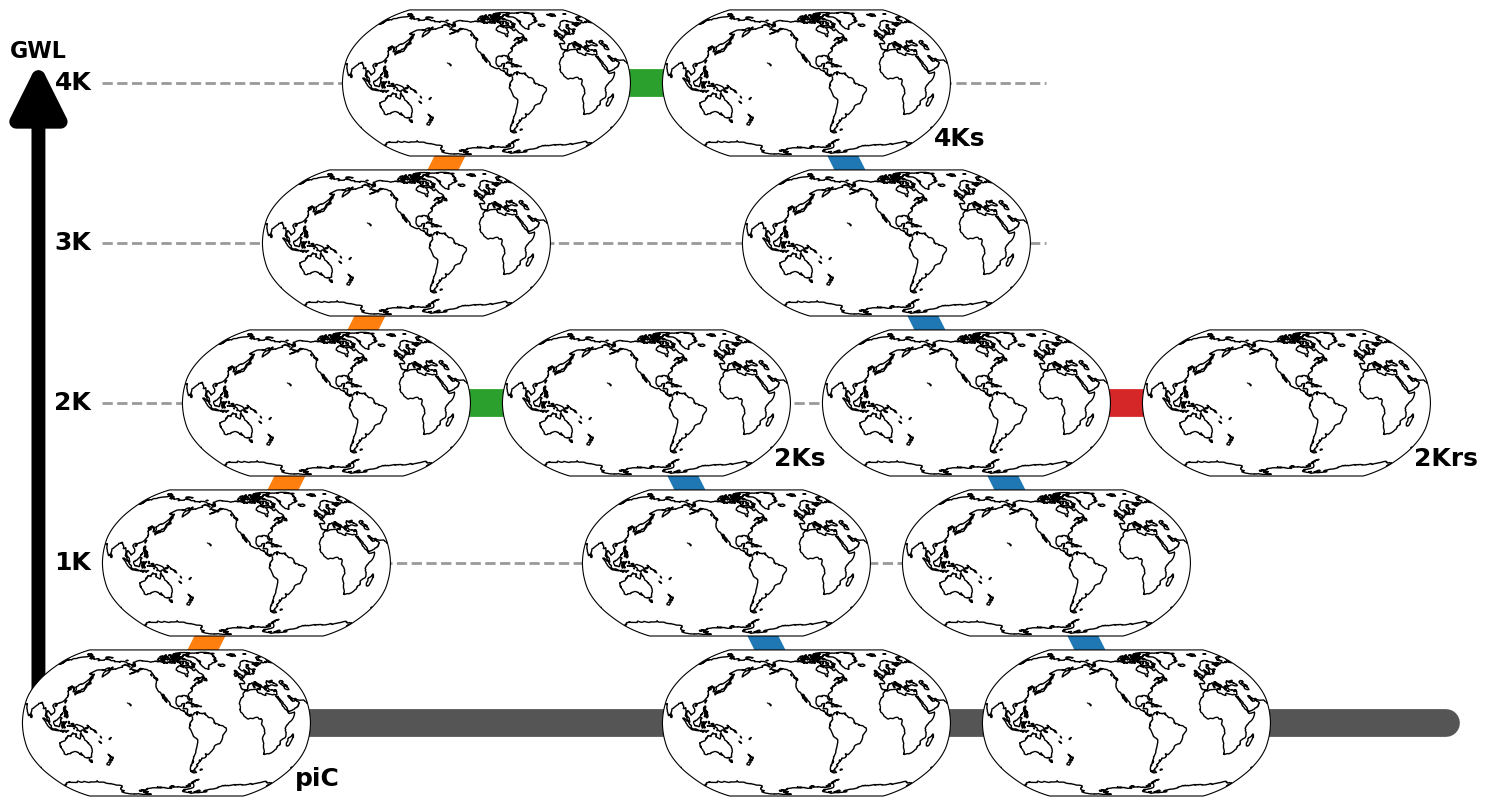

In [3]:
fig, ax = initialize_time_slice_map_plot_large()
fig.savefig('dummy.png')
plt.show()

## Load in some model data 

In [4]:
def get_cstats(varia):

    if varia == 'tas':

        ref_units = ['K','deg K']
        
        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 220
        vmax_ref = 300
        cmap_ref = plt.get_cmap('cmo.thermal',20)

        vmin_anom = -10
        vmax_anom = 10
        cmap_anom = plt.get_cmap('cmo.balance',20)


    elif varia == 'tos':

        ref_units = ['°C','degC', 'deg C']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
    
        vmin_ref = -2
        vmax_ref = 32
        cmap_ref = plt.get_cmap('cmo.thermal',17)

        vmin_anom = -10
        vmax_anom = 10
        cmap_anom = plt.get_cmap('cmo.balance',20)

    elif varia == 'nbp':

        ref_units = ['kg m-2 s-1','kg/m2/s', 'kgC/m2/s']

        plot_anoms = False
        plot_agreement_ref = True
        plot_agreement_anom = True
        
        vmin_ref = -4e-9
        vmax_ref = 4e-9
        cmap_ref = plt.get_cmap('cmo.balance_r',16)

    elif varia == 'fgco2':

        ref_units = ['kg m-2 s-1','kg/m2/s', 'kgC/m2/s']

        plot_anoms = False
        plot_agreement_ref = True
        plot_agreement_anom = True
        
        vmin_ref = -4e-9
        vmax_ref = 4e-9
        cmap_ref = plt.get_cmap('cmo.balance_r',16)

    elif varia == 'intpp':

        ref_units = ['mol m-2 s-1','mol/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 1e-6
        cmap_ref = plt.get_cmap('cmo.algae',18)

        vmin_anom = -3e-7
        vmax_anom = 3e-7
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'npp':

        ref_units = ['kg m-2 s-1','kg/m2/s','kgC/m2/s']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 4e-8
        cmap_ref = plt.get_cmap('cmo.algae',16)

        vmin_anom = -2e-8
        vmax_anom = 2e-8
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'cLand':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 20
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -10
        vmax_anom = 10
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'cSoil':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 20
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -10
        vmax_anom = 10
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    elif varia == 'cVeg':

        ref_units = ['kg m-2','kg/m2']

        plot_anoms = True
        plot_agreement_ref = False
        plot_agreement_anom = True
        
        vmin_ref = 0
        vmax_ref = 20
        cmap_ref = plt.get_cmap('cmo.rain',18)

        vmin_anom = -10
        vmax_anom = 10
        cmap_anom = plt.get_cmap('cmo.curl_r',18)

    
    cstats = dict()
    cstats['plot_anoms'] = plot_anoms
    cstats['vmin_ref'] = vmin_ref
    cstats['vmax_ref'] = vmax_ref
    cstats['cmap_ref'] = cmap_ref
    cstats['plot_agreement_ref'] = plot_agreement_ref  

    if plot_anoms == True:
        cstats['vmin_anom'] = vmin_anom
        cstats['vmax_anom'] = vmax_anom
        cstats['cmap_anom'] = cmap_anom  
        cstats['plot_agreement_anom'] = plot_agreement_anom

    return cstats, ref_units
    

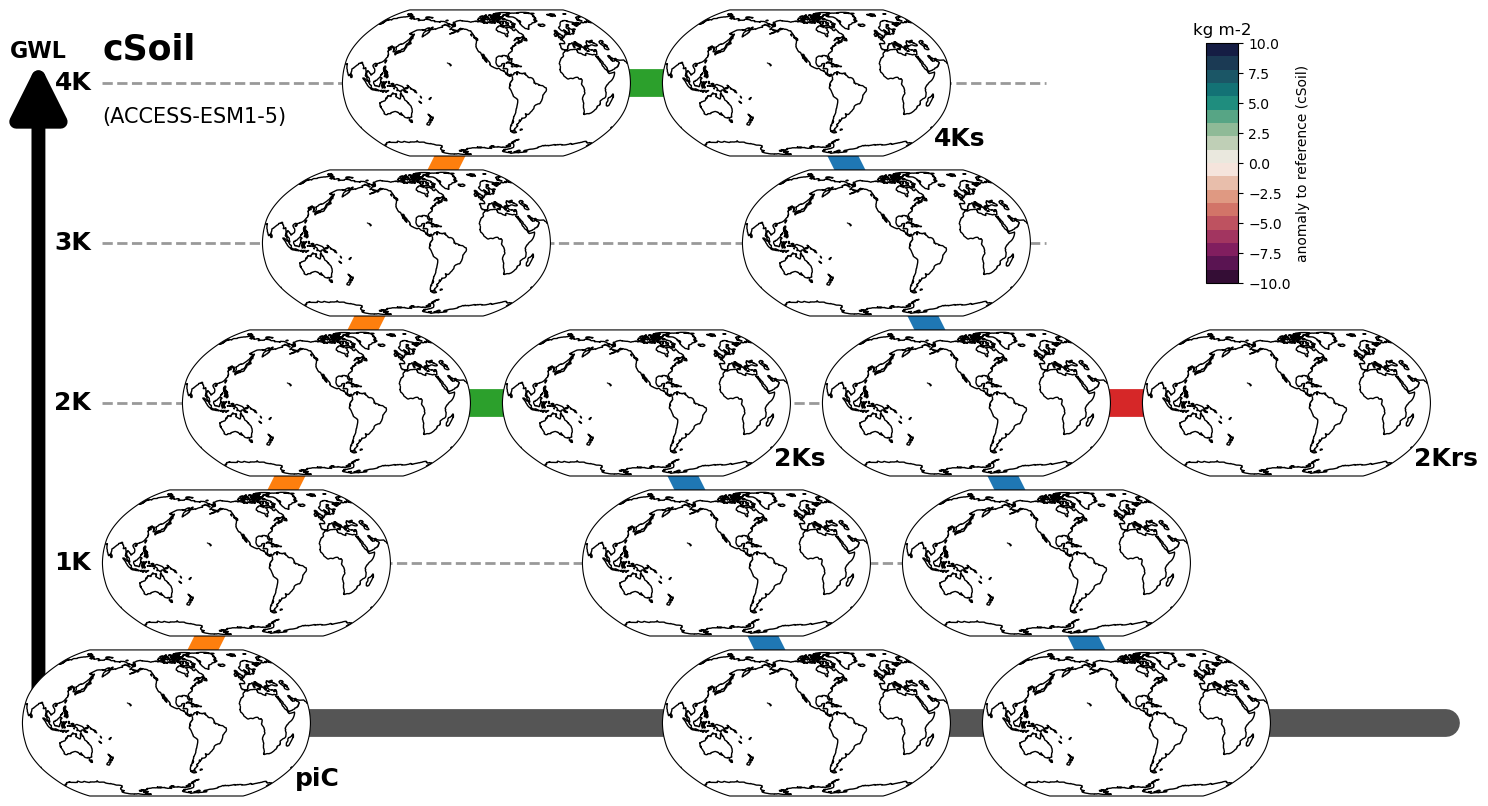

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


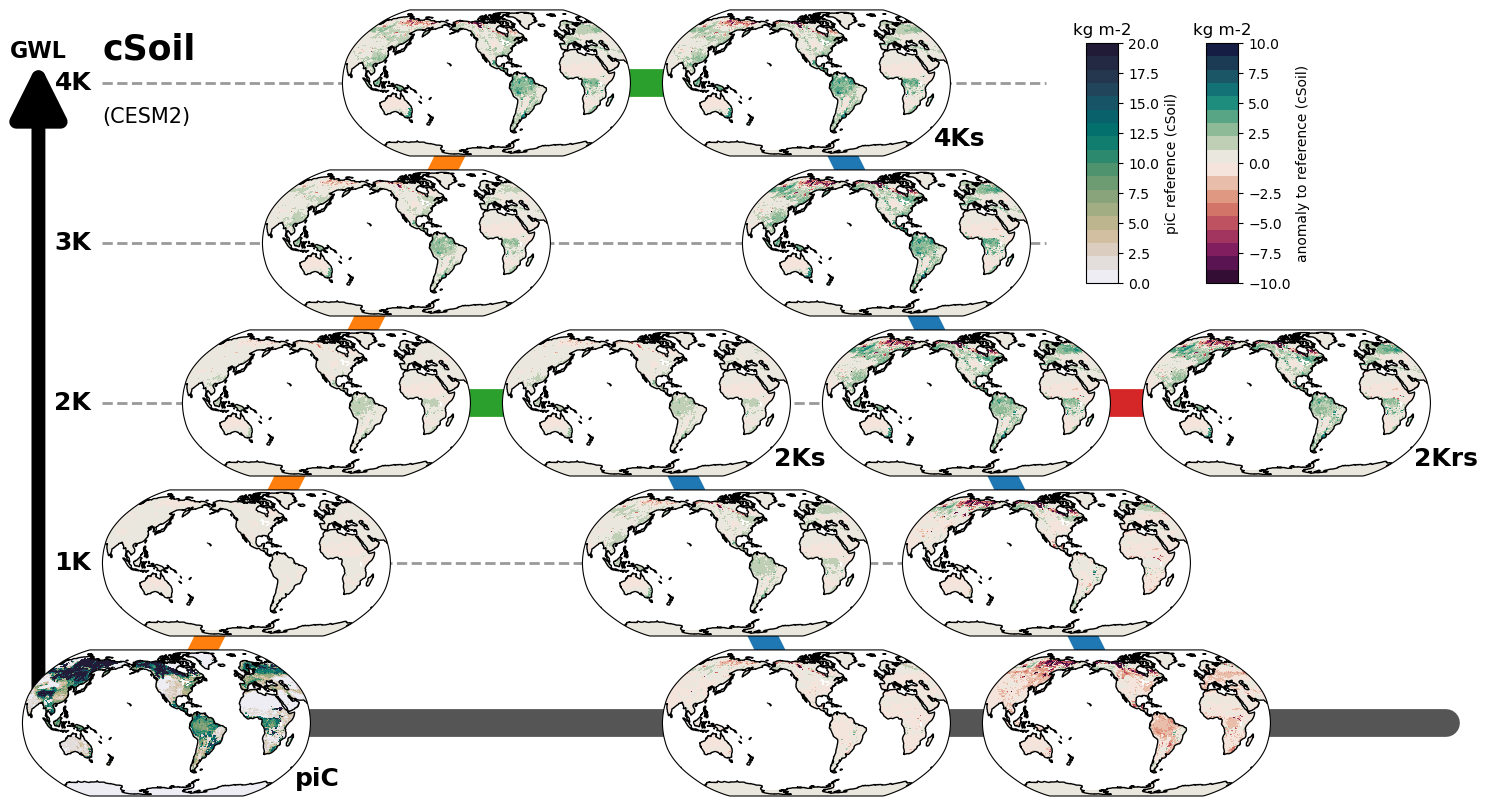

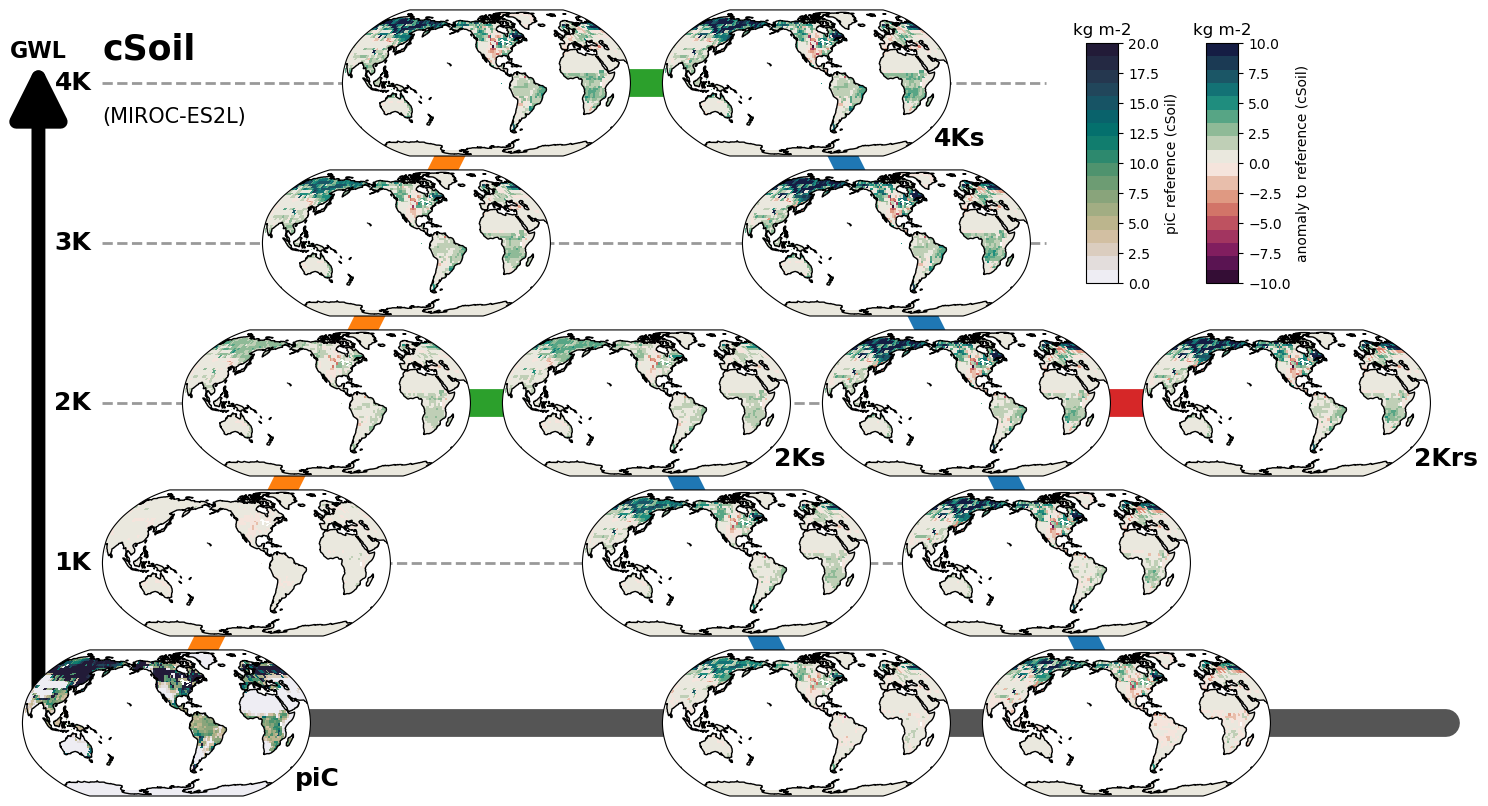

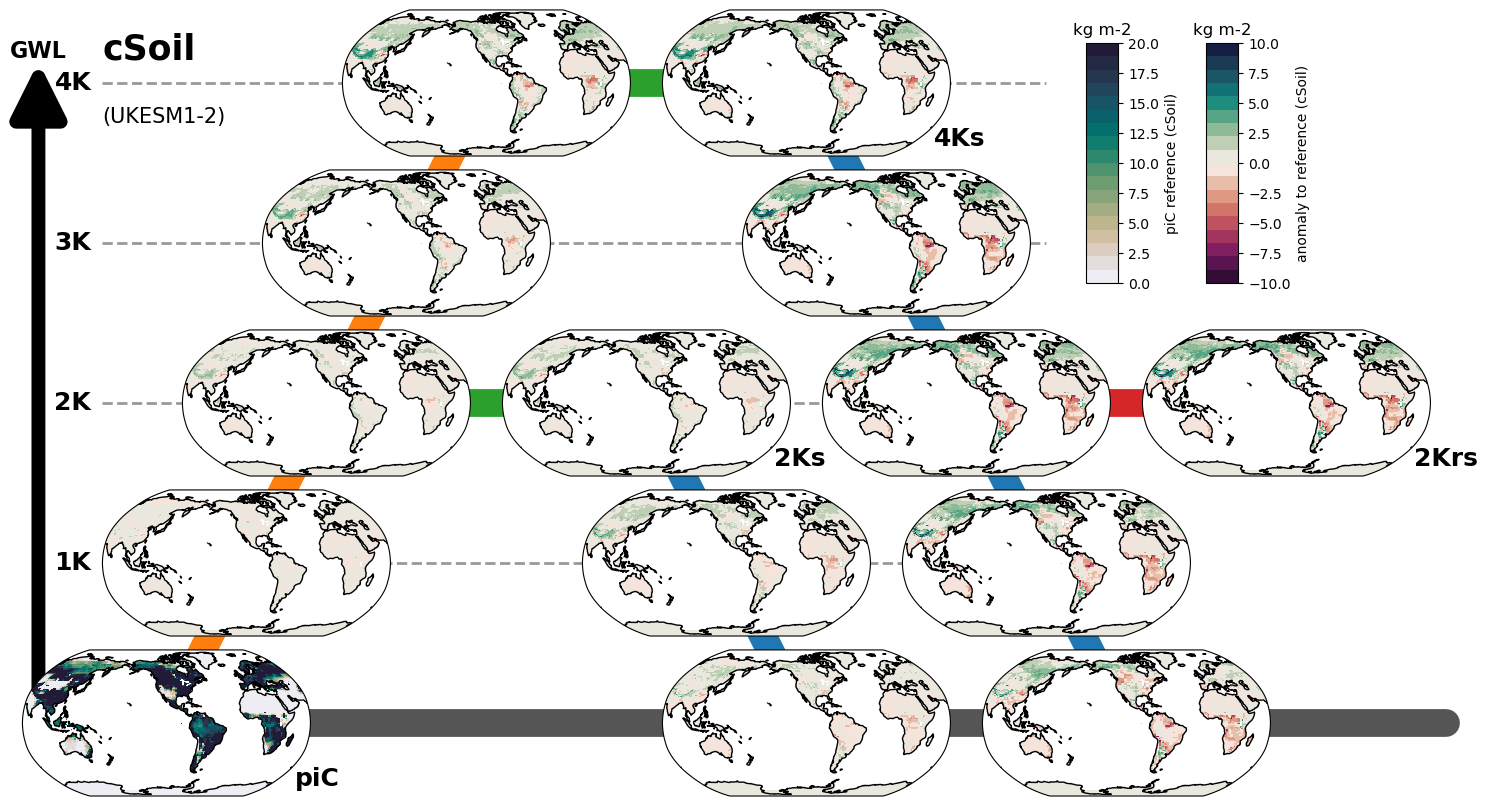

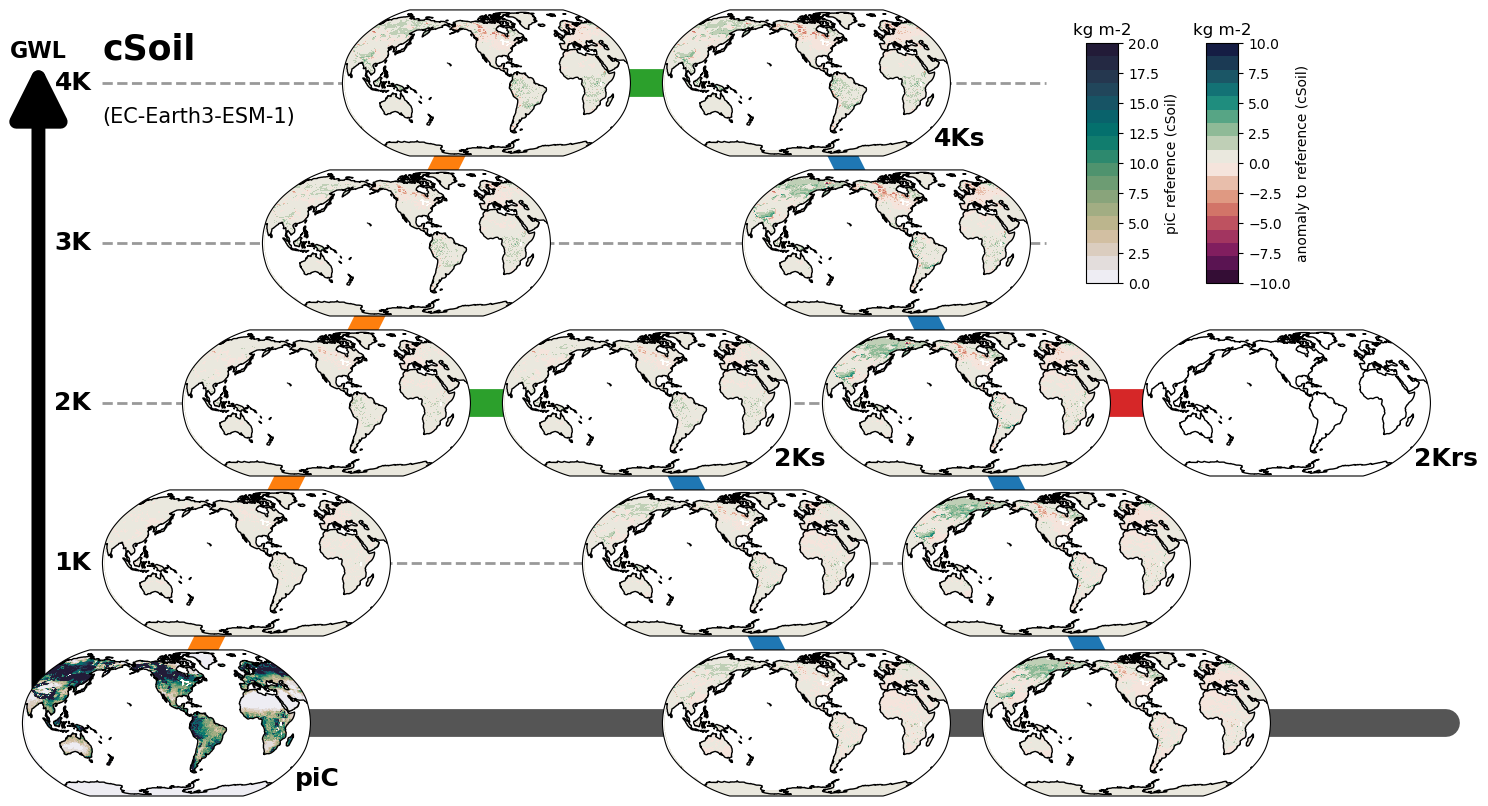

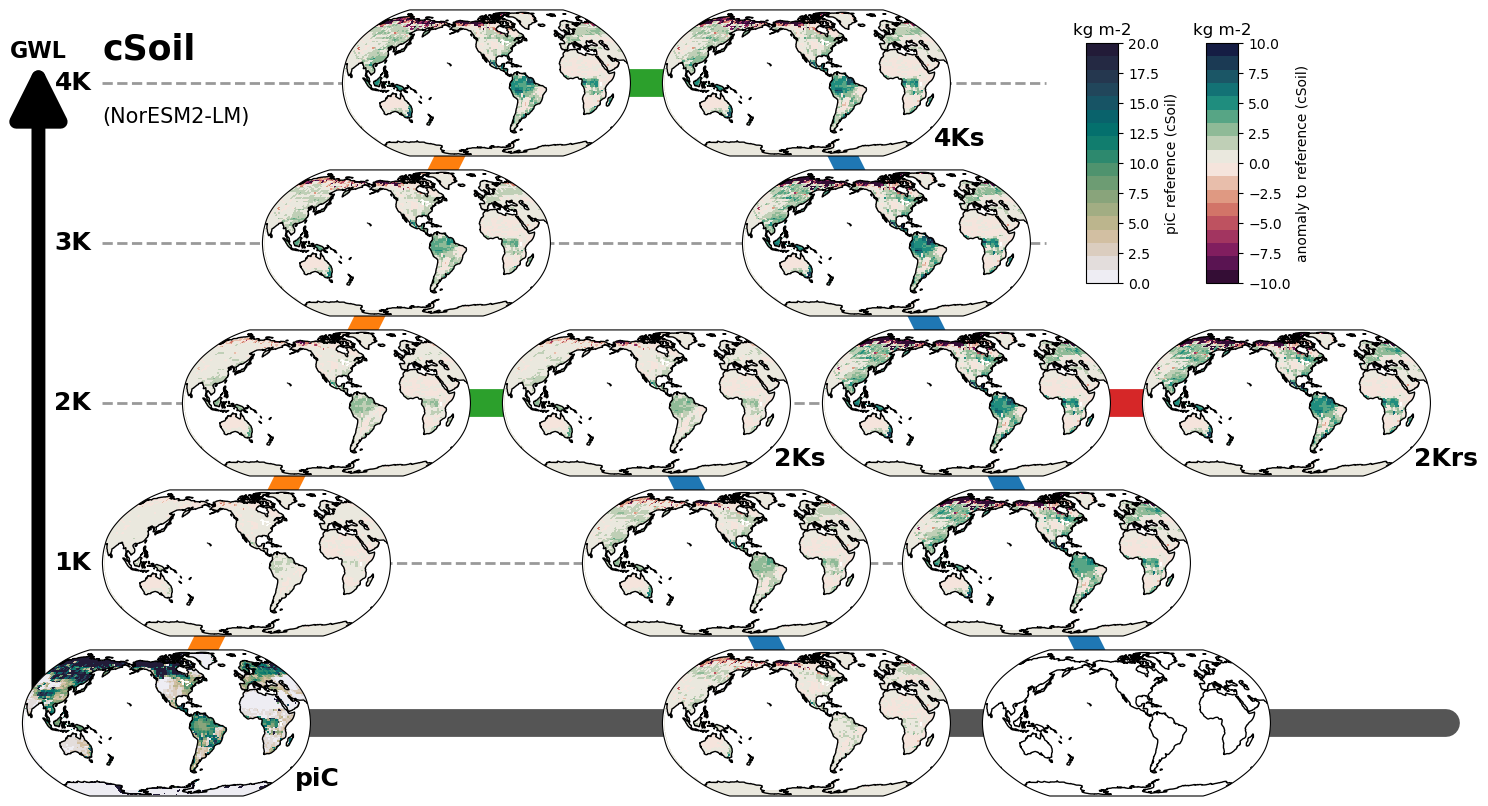

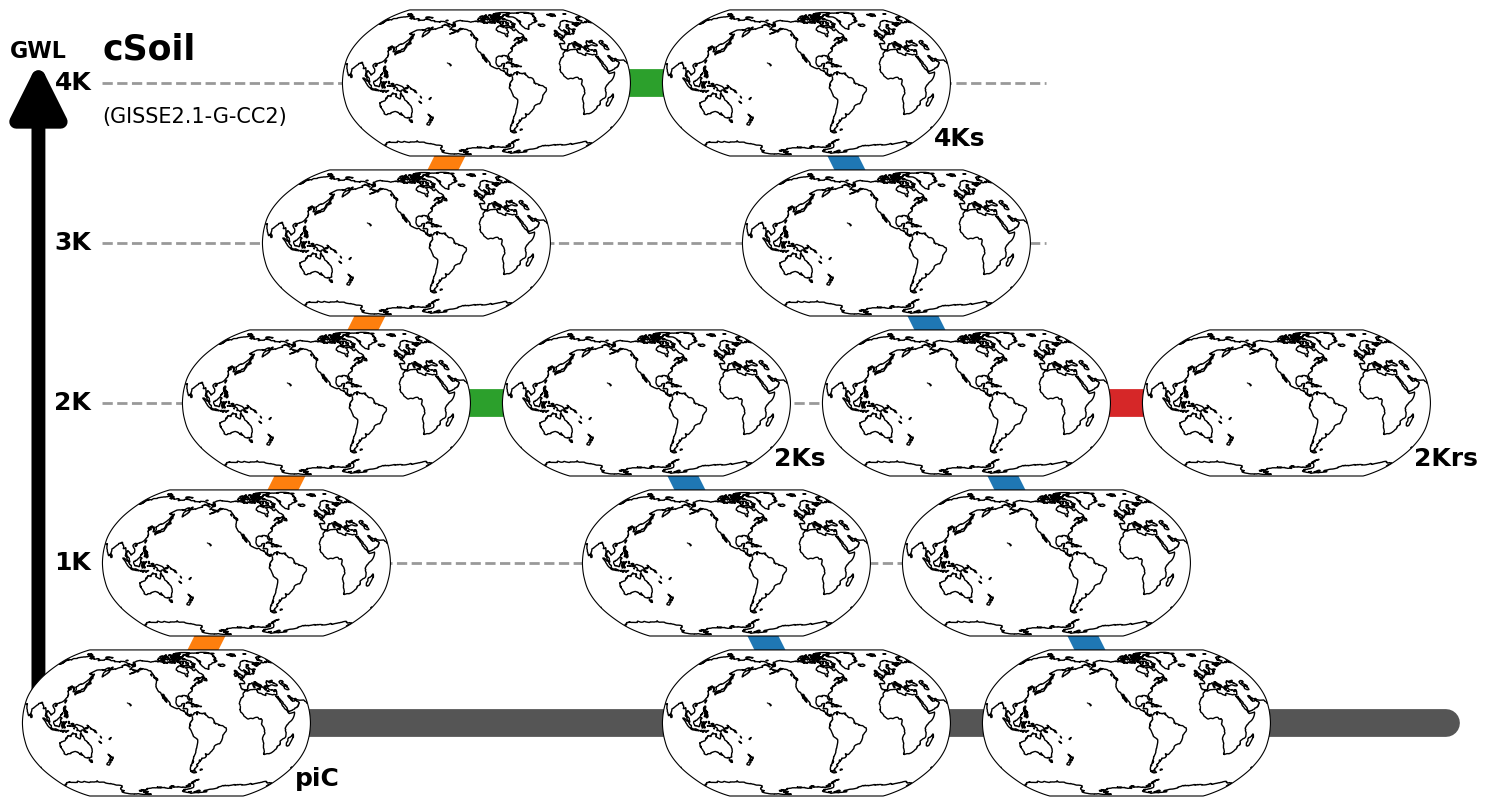

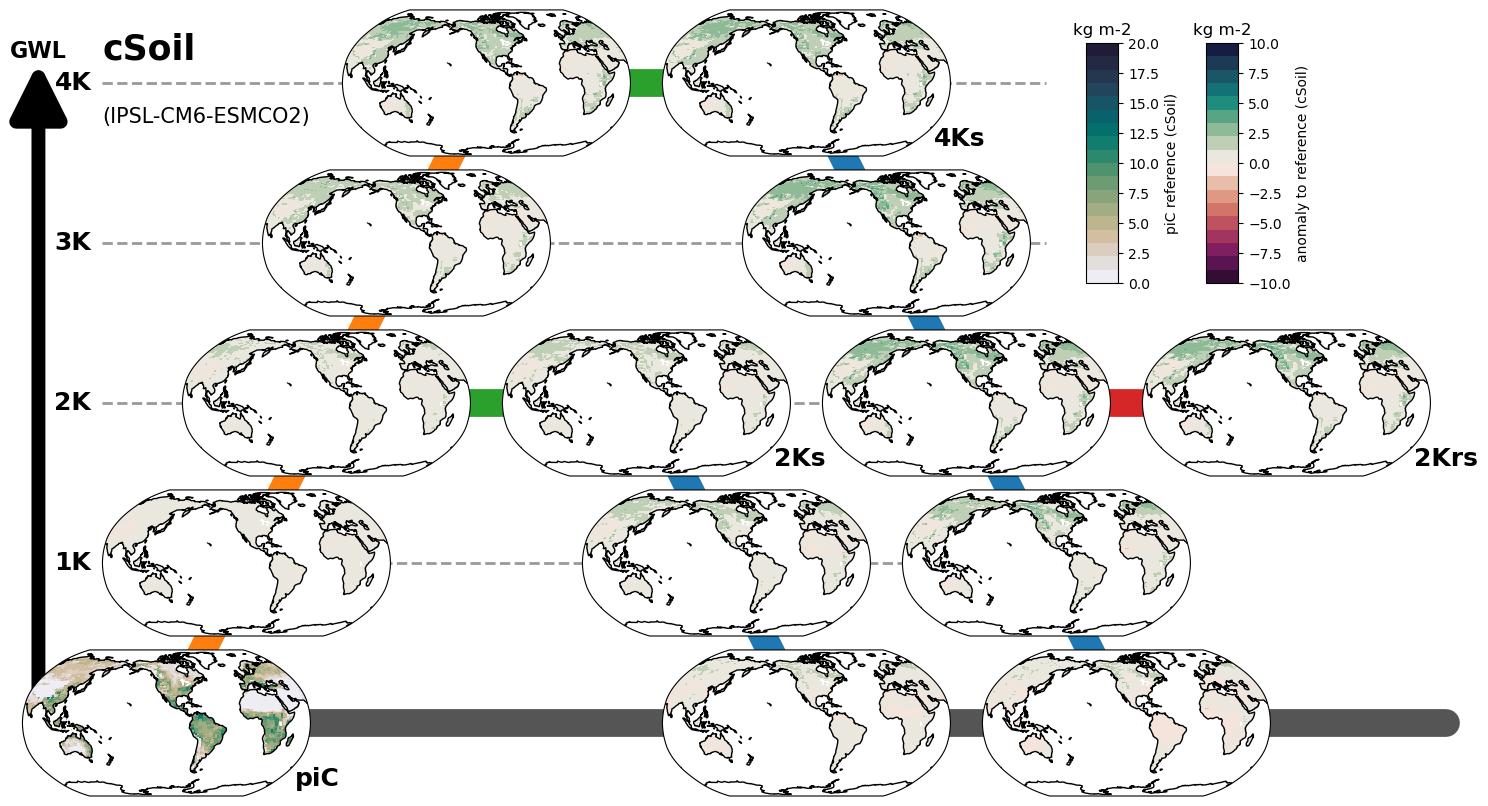

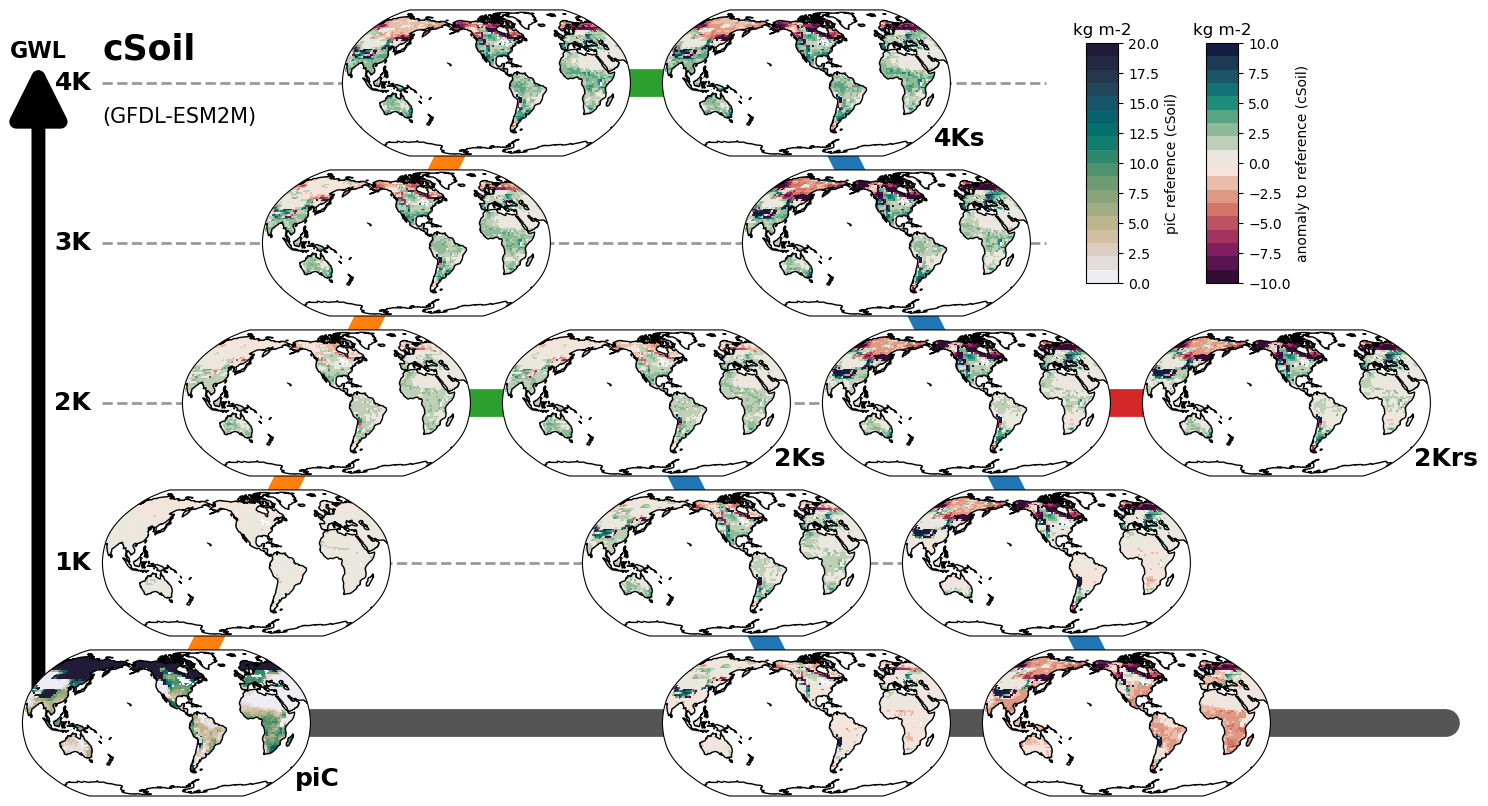

In [32]:
models = ['ACCESS-ESM1-5','CESM2','MIROC-ES2L','UKESM1-2','EC-Earth3-ESM-1','NorESM2-LM','GISSE2.1-G-CC2','IPSL-CM6-ESMCO2','GFDL-ESM2M'] #['NorESM2-LM']##['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['CESM2'] ['GISSE2.1-G-CC2','GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','']
varias = ['cSoil'] #['cVeg']#['cSoil']#['cLand']#['cSoil']#,'cVeg' ['cLand']#['intpp','npp'] ##['fgco2','nbp'] #['tas']##['tos']#['fgco2']#['cLand']#['cSoil']#['tos']#['tas']#['fgco2','nbp']#

temporal_stat = 'mean'

ax_names = ['piC_at_start',
            'rampup_1K',
            'rampup_2K',
            'rampup_3K',
            'rampup_4K',
            'stab2K',
            'stab4K',
            'rampdn2K_1K',
            'rampdn2K_0K',
            'rampdn4K_3K',
            'rampdn4K_2K',     
            'rampdn4K_1K',
            'rampdn4K_0K',             
            'restab2K',     
           ]

            
for model in models:
    fig, ax = initialize_time_slice_map_plot_large()
    varia_string = " & ".join(varias)
    fig.text(0.06,0.93,varia_string,fontsize=25,fontweight='bold')
    fig.text(0.06,0.85,f'({model})',fontsize=15)#,fontweight='bold')

    for vdx,varia in enumerate(varias):
        # get the unique dataset
        #varia = varias[0]
        file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
        if os.path.exists(file_path):
            ds = xr.open_dataset(file_path)
        else:
            continue
        cstats,ref_units = get_cstats(varia)

        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask
        with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
            ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
            land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
            atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)
        if varia in ['nbp','npp','cLand','cSoil','cVeg']:
            mask = land_mask
        elif varia in ['tos','fgco2','intpp']:
            mask = ocean_mask
        elif varia in ['tas']:
            mask = atmosphere_mask
        else:
            raise Exception('Mask not yet implemented for this variable')

        # Check if all the units are the same for rampup_1K_mean 
        for ax_name in ax_names:
            if f'{ax_name}_{temporal_stat}' in ds.keys():
                unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                if unit not in ref_units:
                    print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                    if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                        conv_factor = 12.0107/10**8
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    else:
                        raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
        
        for axn in ax_names:
            
            #if 'restab2K' in axn and model in ['GISSE2.1-G-CC2','EC-Earth3-ESM-1']:
            #    continue
            if f'{axn}_{temporal_stat}' in ds.keys():
                #print('is there')

                if axn == 'piC_at_start':
                    da = ds[f'{axn}_{temporal_stat}'] * mask
                    c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                    if vdx == 0:
                        xloc_ref = 0.675
                    elif vdx == 1:
                        xloc_ref = 0.825
                    cbax_ref = fig.add_axes([xloc_ref,0.65,0.02,0.3])
                    cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'piC reference ({varia})')
                    cbar_ref.ax.set_title(ds.unit)
                else:
                    if cstats['plot_anoms'] == True:
                        if f'piC_at_start_{temporal_stat}' in ds.keys():
                            da = (ds[f'{axn}_{temporal_stat}'] - ds[f'piC_at_start_{temporal_stat}']) * mask
                            c_anom = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_anom'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_anom'],vmax=cstats['vmax_anom'])  
                    else:
                        da = ds[f'{axn}_{temporal_stat}'] * mask
                        c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                        cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'all panels ({varia})')
        
        if cstats['plot_anoms'] == True:
            if vdx == 0:
                xloc_anom = 0.75
            elif vdx == 1:
                xloc_anom = 0.9
            cbax_anom = fig.add_axes([xloc_anom,0.65,0.02,0.3])
            cbar_anom = plt.colorbar(c_anom,cax=cbax_anom,label=f'anomaly to reference ({varia})')
            cbar_anom.ax.set_title(ds.unit)
        

    plot_dir = f'./../03_plots/global_time_slice_maps/{"_".join(varias)}/ref_first_year_of_rampup_win_21yr/{temporal_stat}'
    os.makedirs(plot_dir,exist_ok = True)
    plot_filename = f'{"_".join(varias)}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.png'
    fig.savefig(f'{plot_dir}/{plot_filename}')

    plt.show()


## Plot the multimodel mean with model agreement as hatching

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


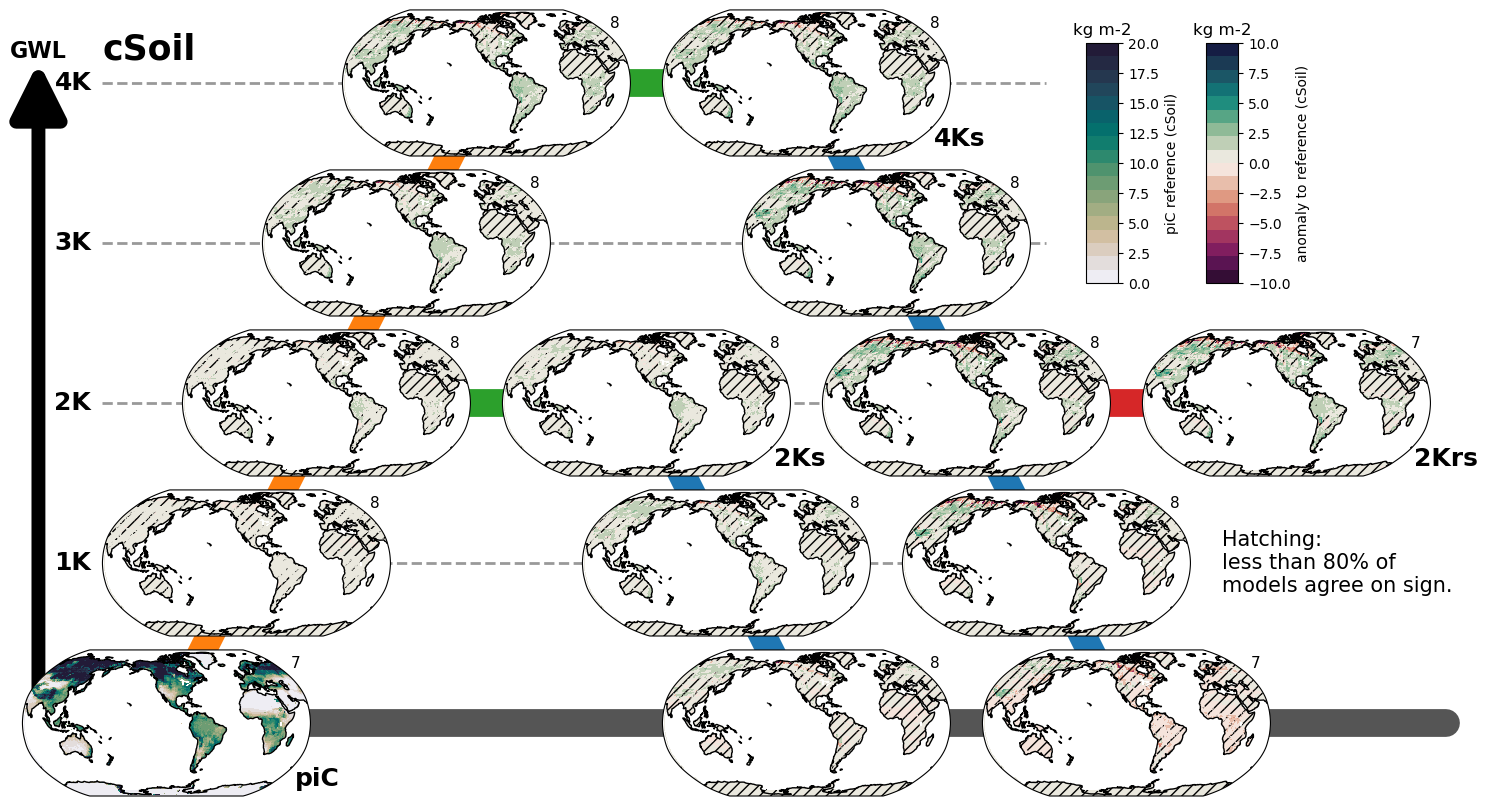

In [33]:
agreement_type = 'sign'
agreement_level = 0.8 #0.75
#varias = ['tos']#['intpp','npp']#['fgco2','nbp']#['tas']#['cLand']#['cSoil']#['tos']#['tas']#['fgco2','nbp']#


def compute_disagreement(da,agreement_level=0.8,agreement_type = 'sign'):

    if agreement_type == 'sign':
        
        # positive and negative counts
        n_pos = (da > 0).sum(dim="model")
        n_neg = (da < 0).sum(dim="model")
        
        # number of non-NaN models
        n_valid = da.notnull().sum(dim="model")
        
        # fraction agreeing on sign
        frac_agree = np.maximum(n_pos, n_neg) / n_valid
        
        # mask where >75% agree
        disagreement = frac_agree < agreement_level

    else:
        raise Exception('This agreement type is not yet implemented.')

    return disagreement



# make the figure
fig, ax = initialize_time_slice_map_plot_large()
varia_string = " & ".join(varias)
fig.text(0.06,0.93,varia_string,fontsize=25,fontweight='bold')

all_number_of_models = []

for vdx,varia in enumerate(varias):
    cstats, ref_units = get_cstats(varia)

    # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
    # use a random file to define the ocean and land and atmosphere mask
    with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
        ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
        land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
        atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)
    if varia in ['nbp','npp','cLand','cSoil','cVeg']:
        mask = land_mask
    elif varia in ['tos','fgco2','intpp']:
        mask = ocean_mask
    elif varia in ['tas']:
        mask = atmosphere_mask
    else:
        raise Exception('Mask not yet implemented for this variable')


    # merge all the models into one dataset (and make sure that the units are the same)
    all_datasets = []
    for model in models:
        file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
        if os.path.exists(file_path):
            ds = xr.open_dataset(file_path)
        else:
            continue
        # add model coordinate
        ds = ds.expand_dims(model=[model])
        # Check if all the units are the same for rampup_1K_mean 
        for ax_name in ax_names:
            if f'{ax_name}_{temporal_stat}' in ds.keys():
                unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                if unit not in ref_units:
                    print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                    if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                        conv_factor = 12.0107/10**8
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                        conv_factor = 1/1000
                        ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                        ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                        ds.attrs['unit'] = ref_units[0]
                    else:
                        raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
        all_datasets.append(ds)        
    ds_all = xr.concat(all_datasets, dim="model", coords='minimal', compat='override')

    
    # count the number of available models for each slice (i.e. maximum of non-nan values along the model dimension)
    number_of_models = dict()
    for ax_name in ax_names:
        number_of_models[f'{ax_name}_{temporal_stat}'] = int(ds_all[f'{ax_name}_{temporal_stat}'].notnull().sum(dim="model").max())
    all_number_of_models.append(number_of_models)
    
    for axn in ax_names:
        
        if axn == 'piC_at_start':
            da = ds_all[f'{axn}_{temporal_stat}'].mean(dim='model') * mask
            c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
            if vdx == 0:
                xloc_ref = 0.675
            elif vdx == 1:
                xloc_ref = 0.825
            cbax_ref = fig.add_axes([xloc_ref,0.65,0.02,0.3])
            cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'piC reference ({varia})')
            cbar_ref.ax.set_title(ds.unit)
            if cstats['plot_agreement_ref'] == True:
                #print('calculating disagreement')
                disagreement = compute_disagreement(ds_all[f'{axn}_{temporal_stat}'],agreement_level=agreement_level,agreement_type=agreement_type) * mask
                ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
        
        else:
            if cstats['plot_anoms'] == True:
                da_anom = (ds_all[f'{axn}_{temporal_stat}'] - ds_all[f'piC_at_start_{temporal_stat}'])
                da = da_anom.mean(dim='model') * mask
                c_anom = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_anom'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_anom'],vmax=cstats['vmax_anom'])  
                if cstats['plot_agreement_anom'] == True:
                    #print('calculating disagreement')
                    disagreement = compute_disagreement(da_anom,agreement_level=agreement_level,agreement_type=agreement_type) * mask
                    ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
            else:
                da = ds_all[f'{axn}_{temporal_stat}'].mean(dim='model') * mask
                c_ref = ax[axn].pcolormesh(da.lon,da.lat,da,cmap=cstats['cmap_ref'],transform=ccrs.PlateCarree(),vmin=cstats['vmin_ref'],vmax=cstats['vmax_ref'])
                cbar_ref = plt.colorbar(c_ref,cax=cbax_ref,label=f'all panels ({varia})')
                if cstats['plot_agreement_ref'] == True:
                    #print('calculating disagreement')
                    disagreement = compute_disagreement(ds_all[f'{axn}_{temporal_stat}'],agreement_level=agreement_level,agreement_type=agreement_type) * mask
                    ax[axn].contourf(disagreement.lon,disagreement.lat,disagreement,levels=[0.5, 1],hatches=["///"],colors="none",transform=ccrs.PlateCarree())
                        
    if cstats['plot_anoms'] == True:
        if vdx == 0:
            xloc_anom = 0.75
        elif vdx == 1:
            xloc_anom = 0.9
        cbax_anom = fig.add_axes([xloc_anom,0.65,0.02,0.3])
        cbar_anom = plt.colorbar(c_anom,cax=cbax_anom,label=f'anomaly to reference ({varia})')
        cbar_anom.ax.set_title(ds.unit)

    fig.text(0.76,0.3,f'Hatching:\nless than {int(agreement_level*100)}% of \nmodels agree on sign.',fontsize=15,va='center')

# add the numbers of how many models are available
for axn in ax_names:
    number_list = []
    for vdx,varia in enumerate(varias):    
        number_list.append(str(all_number_of_models[vdx][f'{axn}_{temporal_stat}']))
    if len(number_list)>1:
        number_string = " & ".join(number_list)
    else:
        number_string = str(number_list[0])
    ax[axn].text(0.93,0.96,number_string,ha='left',va='top',color='k',fontsize=11,transform=ax[axn].transAxes)

plot_dir = f'./../03_plots/global_time_slice_maps/{"_".join(varias)}/ref_first_year_of_rampup_win_21yr/{temporal_stat}'
os.makedirs(plot_dir,exist_ok = True)
plot_filename = f'{"_".join(varias)}_MMM_{temporal_stat}_ref_first_year_of_rampup_win21yr.png'
fig.savefig(f'{plot_dir}/{plot_filename}')

plt.show()

## Plot the variable as line plot for a specific focus region

In [34]:
def get_focus_region_mask(foc_reg, da):
    if foc_reg == 'North Atlantic subpolar gyre':
        lon_min = -55
        lon_max = 15
        lat_min = 45
        lat_max = 78
    elif foc_reg == 'Amazon':
        lon_min = -80
        lon_max = -40
        lat_min = -20
        lat_max = 5
    elif foc_reg == 'global':
        lon_min = -180
        lon_max = 180
        lat_min = -90
        lat_max = 90
    elif foc_reg == 'Arctic':
        lon_min = -180
        lon_max = 180
        lat_min = 80
        lat_max = 90
    elif foc_reg == 'Southern Ocean':
        lon_min = -180
        lon_max = 180
        lat_min = -75
        lat_max = -50
    elif foc_reg == 'Boreal':
        lon_min = -180
        lon_max = 180
        lat_min = 50
        lat_max = 75


    mask = xr.where(da.lon>lon_min,1,np.NaN) * xr.where(da.lon<lon_max,1,np.NaN) * xr.where(da.lat<lat_max,1,np.NaN) * xr.where(da.lat>lat_min,1,np.NaN) # and da.lat > lat_min and da.lat < lat_max, 1, np.NaN)
    mask_dict = dict()
    mask_dict['lon_min'] = lon_min
    mask_dict['lon_max'] = lon_max
    mask_dict['lat_min'] = lat_min
    mask_dict['lat_max'] = lat_max

    return mask, mask_dict

def get_area(da):
    """
    Compute grid-cell area (m²) for a regular 1° lat/lon grid.

    Parameters
    ----------
    da : xarray.DataArray or xarray.Dataset
        Must contain 1D coordinates `lat` and `lon` in degrees.

    Returns
    -------
    area : xarray.DataArray
        2D array of grid-cell areas with dimensions (lat, lon).
    """

    lat = da.lat
    lon = da.lon

    # Earth radius (m)
    R = 6_371_000

    # Grid spacing in radians
    dlat = np.deg2rad(abs(lat[1] - lat[0]).item())
    dlon = np.deg2rad(abs(lon[1] - lon[0]).item())

    # Latitude bounds
    lat_rad = np.deg2rad(lat)

    lat_bnds_n = lat_rad + dlat / 2
    lat_bnds_s = lat_rad - dlat / 2

    # Area for each latitude band
    area_lat = R**2 * dlon * (
        np.sin(lat_bnds_n) - np.sin(lat_bnds_s)
    )

    # Broadcast to 2D
    area = xr.DataArray(
        area_lat.values[:, np.newaxis] * np.ones(len(lon)),
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="cell_area",
        attrs={"units": "m^2"}
    )

    return area


def collect_series(ax_names, model, weighted_mean, gmst_anom,
                   temporal_stat):

    xvals = []
    yvals = []

    ref_name = f'piC_at_start_{temporal_stat}'

    # reference for y-axis anomaly only
    ref_y = weighted_mean[ref_name].sel(model=model).values

    for ax_name in ax_names:

        # x-axis already anomaly (no reference subtraction)
        x = gmst_anom[ax_name.split(f'_{temporal_stat}')[0]].sel(model=model).values

        # y-axis anomaly relative to reference
        if ax_name == ref_name:
            y = 0
        else:
            y = (
                weighted_mean[ax_name]
                .sel(model=model)
                .values
                - ref_y
            )

        xvals.append(x)
        yvals.append(y)

    return np.array(xvals), np.array(yvals)


def collect_series(ax_names, model, weighted_mean, gmst_anom,
                   temporal_stat):

    xvals = []
    yvals = []

    ref_name = f'piC_at_start_{temporal_stat}'

    # safe reference (y-axis)
    ref_y = weighted_mean[ref_name].reindex(model=[model]).values[0]

    for ax_name in ax_names:

        base_name = ax_name.split(f'_{temporal_stat}')[0]

        # x-axis (already anomaly)
        x = gmst_anom[base_name].reindex(model=[model]).values[0]

        # y-axis anomaly relative to reference
        if ax_name == ref_name:
            y = 0
        else:
            y = (
                weighted_mean[ax_name].reindex(model=[model]).values[0]
                - ref_y
            )

        xvals.append(x)
        yvals.append(y)

    return np.array(xvals), np.array(yvals)



# infer the global mean temperature anomaly
def get_global_mean_temperature_anomaly(model,ax_name):
    
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    if model == 'GISSE2.1-G-CC2':
        freq = 'yearly'
    else:
        freq = 'monthly'

    # now load the time slice file to check for each ax name the 
    
    ds_ts = xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tas/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/tas_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc')
        
    # get the right run
    if ax_name == 'piC_at_start':
        run = 'esm-piControl'
    elif 'rampup' in ax_name:
        run = 'esm-up2p0'
    elif ax_name == f'stab2K':
        run = 'esm-up2p0-gwl2p0'
    elif ax_name == f'stab4K':
        run = 'esm-up2p0-gwl4p0'
    elif 'rampdn2K' in ax_name: #== f'stab4K_{temporal_stat}'
        run = 'esm-up2p0-gwl2p0-50y-dn2p0'
    elif 'rampdn4K' in ax_name: #== f'stab4K_{temporal_stat}'
        run = 'esm-up2p0-gwl4p0-50y-dn2p0'
    elif ax_name == f'restab2K':
        run = 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'
    else:
        raise Exception(f'No run available for the ax_name {ax_name}')

    # now for each time slice, get the slice_start_year and slice_end_year
    if f'{ax_name}_{temporal_stat}' in ds_ts.keys():
        time_slice_start_year = ds_ts[f'{ax_name}_{temporal_stat}'].time_slice_start_year
        time_slice_end_year = ds_ts[f'{ax_name}_{temporal_stat}'].time_slice_end_year
        if np.isnan(time_slice_start_year):
            time_slice_start_year = None
        if np.isnan(time_slice_end_year):
            time_slice_end_year = None
    else:
        time_slice_start_year = None
        time_slice_end_year = None

    # now get the global mean tas time series and compute the mean over the time period
    gmst_filename = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_series/tas/{model}/{run}/{member}/{freq}/global_mean/tas_{model}_{run}_{member}_global_mean.nc'
    if os.path.exists(gmst_filename) and time_slice_start_year is not None and time_slice_end_year is not None:
        gmst_ds = xr.open_dataset(gmst_filename)

        gmst_ds = gmst_ds.convert_calendar(
            'proleptic_gregorian',
            use_cftime=True
        )            

        gmst_slice = gmst_ds.tas_global_mean.sel(time=slice(cftime.DatetimeProlepticGregorian(time_slice_start_year,1,1),cftime.DatetimeProlepticGregorian(time_slice_end_year,12,31))).mean(dim='time').values

        # now get the first year of rampup for reference
        gmst_ref_filename = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_series/tas/{model}/esm-up2p0/{member}/{freq}/global_mean/tas_{model}_esm-up2p0_{member}_global_mean.nc'
        gmst_ref_ds = xr.open_dataset(gmst_ref_filename)
        ref_year = int(model_dict[model].rampup_start_year)
        #print(type(ref_year), ref_year)
        #print(type(gmst_ref_ds.time.values[0]))
        
        gmst_ref_ds = gmst_ref_ds.convert_calendar(
            'proleptic_gregorian',
            use_cftime=True
        )            
        
        gmst_ref_slice = gmst_ref_ds.tas_global_mean.sel(time=slice(cftime.DatetimeProlepticGregorian(ref_year,1,1),cftime.DatetimeProlepticGregorian(ref_year,12,31))).mean(dim='time').values

        temp_anomaly = gmst_slice-gmst_ref_slice
        #print(model,ax_name,gmst_slice, gmst_ref_slice, gmst_slice-gmst_ref_slice)
        
    else:
        #print(f'No tas gmst available for {model}, {run}.')
        temp_anomaly = np.nan

    return temp_anomaly



Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


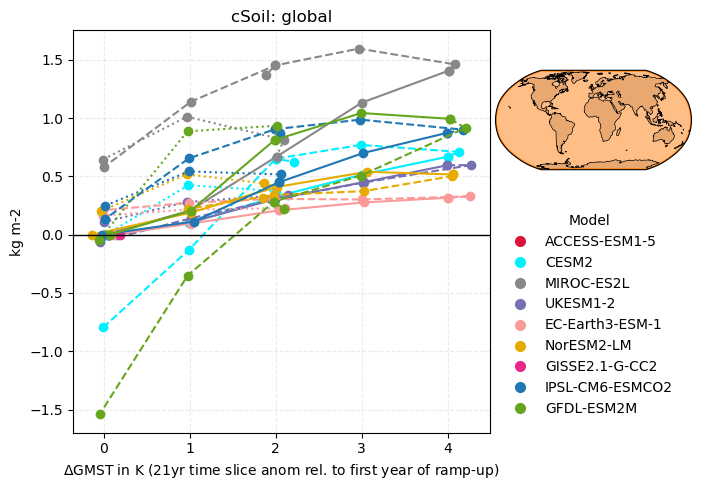

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


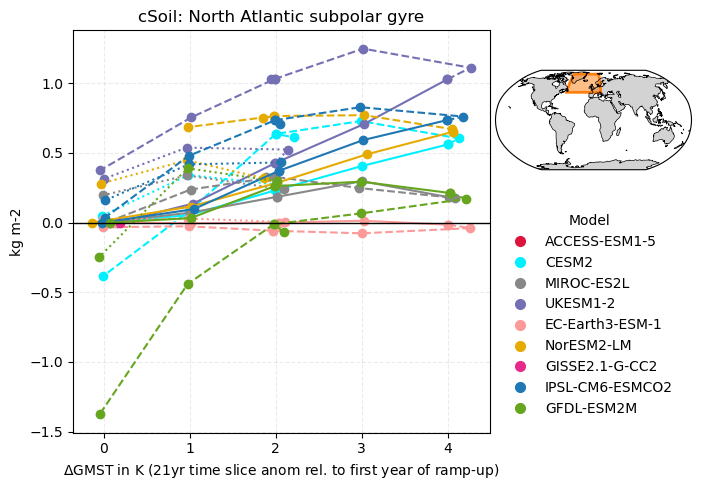

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


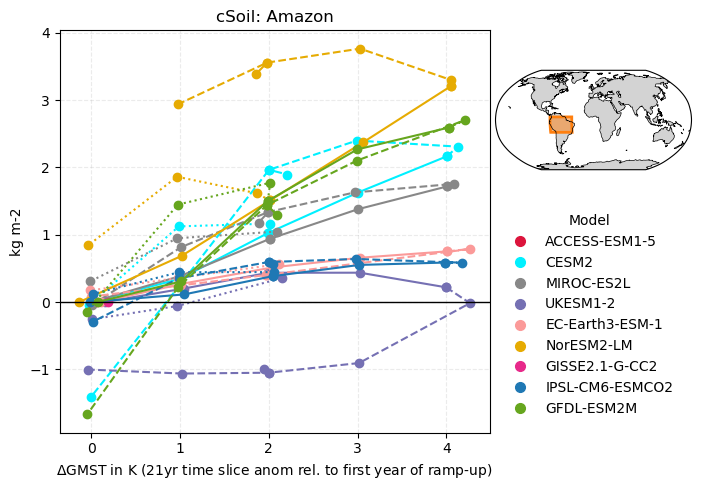

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


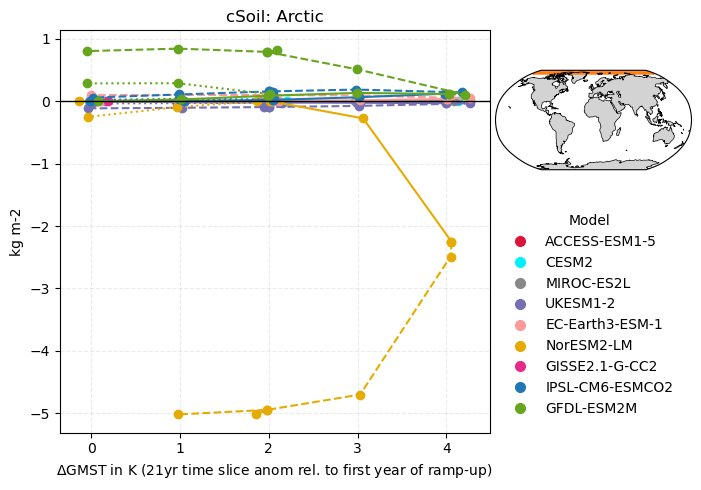

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


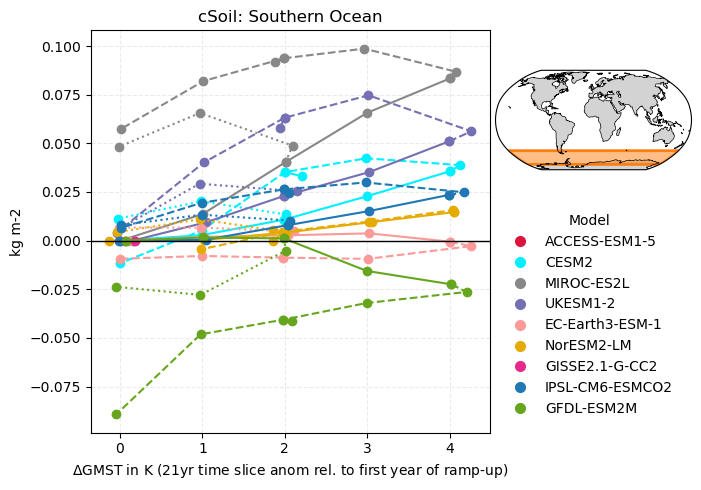

Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.
Need to do some unit conversion: gC/m^2 -> kg m-2.


/tmp/ipykernel_4119621/1778736135.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


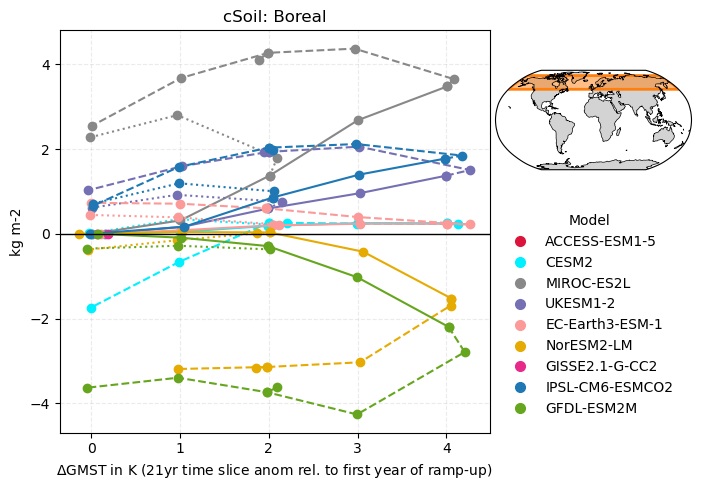

In [35]:
model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

for foc_reg in ['global','North Atlantic subpolar gyre','Amazon','Arctic','Southern Ocean','Boreal']:
    for vdx,varia in enumerate(varias):

        fig, ax = plt.subplots(figsize=(7,5))
        
        cstats, ref_units = get_cstats(varia)
    
        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask

        # for a regular 1x1° global grid, i want to have a land, ocean, atmosphere mask consisting of 1s and np.NaNs
        # use a random file to define the ocean and land and atmosphere mask
        with xr.open_dataset(f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/tos/IPSL-CM6-ESMCO2/ref_first_year_of_rampup_win21yr/mean/tos_IPSL-CM6-ESMCO2_mean_ref_first_year_of_rampup_win21yr.nc') as mask_ds:
            da = mask_ds[f'rampup_1K_{temporal_stat}']
            ocean_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),np.NaN,1)
            land_mask = xr.where(np.isnan(mask_ds.piC_at_start_mean),1,np.NaN)
            atmosphere_mask = xr.where(mask_ds.piC_at_start_mean==1e20,np.NaN,1)        
            mask, mask_dict = get_focus_region_mask(foc_reg, da)
            if varia in ['nbp','npp','cLand','cSoil','cVeg']:
                mask_corr = land_mask
            elif varia in ['tos','fgco2','intpp']:
                mask_corr = ocean_mask
            elif varia in ['tas']:
                mask_corr = atmosphere_mask
            else:
                raise Exception('Mask not yet implemented for this variable')
            mask = mask*mask_corr
        
        area = get_area(da)

        # merge all the models into one dataset (and make sure that the units are the same)
        all_datasets = []
        for model in models:
            file_path = f'/home/ekoehn/jobs/jupyter/TIPMIP_carbon_cycle/01_postprocessed_data/global_time_slice_statistic_maps/{varia}/{model}/ref_first_year_of_rampup_win21yr/{temporal_stat}/{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr.nc'
            if os.path.exists(file_path):
                ds = xr.open_dataset(file_path)
            else:
                continue
            # add model coordinate
            ds = ds.expand_dims(model=[model])
            # Check if all the units are the same for rampup_1K_mean 
            for ax_name in ax_names:
                if f'{ax_name}_{temporal_stat}' in ds.keys():
                    unit = ds[f'{ax_name}_{temporal_stat}'].unit # ds[f'rampup_1K_{temporal_stat}'].unit
                    if unit not in ref_units:
                        print(f'Need to do some unit conversion: {unit} -> {ref_units[0]}.')
                        if unit == 'mmol/m^3 cm/s' and 'kg m-2 s-1' in ref_units:
                            conv_factor = 12.0107/10**8
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'gC/m^2/s' and 'kgC/m2/s' in ref_units:
                            conv_factor = 1/1000
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        elif unit == 'gC/m^2' and 'kg m-2' in ref_units:
                            conv_factor = 1/1000
                            ds[f'{ax_name}_{temporal_stat}'] = ds[f'{ax_name}_{temporal_stat}']*conv_factor
                            ds[f'{ax_name}_{temporal_stat}'].attrs['unit'] = ref_units[0]
                            ds.attrs['unit'] = ref_units[0]
                        else:
                            raise ValueError(f"Unit mismatch for {model}, {varia}: {unit} vs reference {ref_units}. Cannot convert.")
            all_datasets.append(ds)        
        ds_all = xr.concat(all_datasets, dim="model", coords='minimal', compat='override')

        ## Do the area weighted averaging in the masked region
        numerator = (ds_all*mask*area).sum(dim=('lat','lon'))
        denominator = (mask*area).sum(dim=('lat','lon'))
        weighted_mean = numerator/denominator
        weighted_mean = xr.where(numerator==0,np.nan,weighted_mean)

        # Now get the global mean temperature anomaly for each slice
        gmst_dum = {}
        for ax_name in ax_names:
            anom_vec = []
            for model in models:
                gmst_anom = get_global_mean_temperature_anomaly(model, ax_name)
                anom_vec.append(gmst_anom)
            gmst_dum[ax_name] = (["model"], anom_vec)
        gmst_anom_ds = xr.Dataset(
            data_vars=gmst_dum,
            coords={"model": models})

        
#
        for model in models:
        
            # scatter points
            for ax_name in ax_names:

                tas_global = gmst_anom_ds[ax_name].sel(model=model).values
        
                if ax_name == f'piC_at_start_{temporal_stat}':
                    varia_slice = 0        
                else:
                    da_dum = weighted_mean[f'{ax_name}_{temporal_stat}']
                    ref_dum = weighted_mean[f'piC_at_start_{temporal_stat}']
                    
                    if model in da_dum.coords['model'].values and model in ref_dum.coords['model'].values:
                        varia_slice = (
                            da_dum.sel(model=model).item()
                            - ref_dum.sel(model=model).item()
                        )
                    else:
                        varia_slice = np.nan
                    #varia_slice = (
                    #    da_dum.reindex(model=[model]).values[0]
                    #    - ref_dum.reindex(model=[model]).values[0]
                    #)

                    #tas_global = (
                    #    weighted_mean_global[f'{ax_name}_{temporal_stat}']
                    #    .sel(model=model)
                    #    .values
                    #    - weighted_mean_global[f'piC_at_start_{temporal_stat}']
                    #    .sel(model=model)
                    #    .values
                    #)
        
                #if tas_global != 0 and varia_slice != 0:
                #    ax.scatter(
                #        tas_global,
                #        varia_slice,
                #        20,
                #        model_dict[model].color_id,
                #        zorder=10
                #    )
        
            # line groups
            rampup_names = [
                f'piC_at_start_{temporal_stat}',
                f'rampup_1K_{temporal_stat}',
                f'rampup_2K_{temporal_stat}',
                f'rampup_3K_{temporal_stat}',
                f'rampup_4K_{temporal_stat}'
            ]
        
            rampdn2K_names = [
                f'rampup_2K_{temporal_stat}',
                f'stab2K_{temporal_stat}',
                f'rampdn2K_1K_{temporal_stat}',
                f'rampdn2K_0K_{temporal_stat}'
            ]
        
            rampdn4K_names = [
                f'rampup_4K_{temporal_stat}',
                f'stab4K_{temporal_stat}',
                f'rampdn4K_3K_{temporal_stat}',
                f'rampdn4K_2K_{temporal_stat}',
                f'rampdn4K_1K_{temporal_stat}',
                f'rampdn4K_0K_{temporal_stat}'
            ]
        
            restab2K_names = [
                f'rampdn4K_2K_{temporal_stat}',
                f'restab2K_{temporal_stat}'
            ]
        
            rampup_x, rampup_y = collect_series(
                rampup_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat
            )
        
            rampdn2K_x, rampdn2K_y = collect_series(
                rampdn2K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat
            )
        
            rampdn4K_x, rampdn4K_y = collect_series(
                rampdn4K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat
            )
        
            restab2K_x, restab2K_y = collect_series(
                restab2K_names,
                model,
                weighted_mean,
                gmst_anom_ds,
                temporal_stat
            )
        
            # plot lines
            color = model_dict[model].color_id
        
            ax.plot(rampup_x, rampup_y, color=color,marker='o')
            ax.plot(rampdn2K_x, rampdn2K_y, color=color, linestyle=':',marker='o')
            ax.plot(rampdn4K_x, rampdn4K_y, color=color, linestyle='--',marker='o')
            ax.plot(restab2K_x, restab2K_y, color=color, linestyle='-.',marker='o')

        ax.set_title(f'{varia}: {foc_reg}')
        ax.set_xlabel(r'$\Delta$GMST in K (21yr time slice anom rel. to first year of ramp-up)')
        ax.set_ylabel(ref_units[0])
        ax.grid(alpha=0.25,linestyle='--')
        ax.axhline(0,color='k',linewidth=1)

        # create legend handles
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker='o',
                color='none',
                markerfacecolor=model_dict[model].color_id,
                markeredgecolor=model_dict[model].color_id,
                markersize=7,
                label=model
            )
            for model in models
        ]
        
        ax.legend(
            handles=legend_handles,
            title='Model',
            loc='lower left',
            frameon=False,
            bbox_to_anchor=(1.01,0.01)
        )

        # add inset axis in the top-right of the figure
        ax_map = fig.add_axes([0.715, 0.6, 0.28, 0.3], projection=ccrs.Robinson())
        ax_map.set_global()
        ax_map.add_feature(cfeature.LAND, facecolor="lightgray")
        ax_map.add_feature(cfeature.OCEAN, facecolor="white")
        ax_map.coastlines(linewidth=0.5)
    
        rect = mpatches.Rectangle(
            (mask_dict['lon_min'], mask_dict['lat_min']),
            mask_dict['lon_max'] - mask_dict['lon_min'],
            mask_dict['lat_max'] - mask_dict['lat_min'],
            linewidth=2,
            edgecolor="C1",
            facecolor="#ff7f0e80",
            transform=ccrs.PlateCarree()
        )
        
        ax_map.add_patch(rect)

        plt.tight_layout()
        plot_dir = f'./../03_plots/global_time_slice_maps_line_plots/{varia}/ref_first_year_of_rampup_win_21yr/{temporal_stat}/'
        os.makedirs(plot_dir,exist_ok=True)
        plot_filename =f"{varia}_{model}_{temporal_stat}_ref_first_year_of_rampup_win21yr_{foc_reg.replace(' ','_')}.png"
        fig.savefig(f'{plot_dir}/{plot_filename}')
        plt.show()
